# LAB 05 — Matja e Madhësive Bazë: Gjatësia, Masa dhe Koha


Ky raport paraqet:
- regjistrimin e të dhënave eksperimentale
- llogaritjen e mesatares dhe pasigurisë
- analizën me **NumPy**
- paraqitjen grafike të rezultateve


## Qëllimi

Në këtë laborator studiohen tre madhësi bazë fizike:
1. **Gjatësia**
2. **Masa**
3. **Koha**

Për secilën madhësi bëhen matje të përsëritura, llogaritet vlera mesatare dhe vlerësohet pasiguria.

Në përgjithësi, çdo rezultat raportohet në formën:

$$x = x_{mat} \pm \Delta x$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11


## Funksione ndihmëse

Këto funksione përdoren për të llogaritur:
- mesataren
- devijimin standard
- pasigurinë statistikore të mesatares
- pasigurinë totale


In [2]:
def analiza_matjeve(te_dhenat, pasiguria_instrumentale):
    te_dhenat = np.array(te_dhenat, dtype=float)
    N = len(te_dhenat)
    mesatarja = np.mean(te_dhenat)
    std = np.std(te_dhenat, ddof=1) if N > 1 else 0.0
    pasiguria_statistike = std / np.sqrt(N) if N > 1 else 0.0
    pasiguria_totale = np.sqrt(pasiguria_instrumentale**2 + pasiguria_statistike**2)
    return {
        'N': N,
        'mesatarja': mesatarja,
        'std': std,
        'pasiguria_statistike': pasiguria_statistike,
        'pasiguria_instrumentale': pasiguria_instrumentale,
        'pasiguria_totale': pasiguria_totale
    }

def printo_rezultatin(emri, njesia, rezultat):
    print(f"--- {emri} ---")
    print(f"Numri i matjeve: {rezultat['N']}")
    print(f"Mesatarja = {rezultat['mesatarja']:.4f} {njesia}")
    print(f"Devijimi standard = {rezultat['std']:.4f} {njesia}")
    print(f"Pasiguria statistikore = {rezultat['pasiguria_statistike']:.4f} {njesia}")
    print(f"Pasiguria instrumentale = {rezultat['pasiguria_instrumentale']:.4f} {njesia}")
    print(f"Pasiguria totale = {rezultat['pasiguria_totale']:.4f} {njesia}")
    print(f"Rezultati final: {emri} = ({rezultat['mesatarja']:.4f} ± {rezultat['pasiguria_totale']:.4f}) {njesia}")


# Pjesa A — Matja e Gjatësisë

Më poshtë janë dhënë **shembuj matjesh**. 

Rregull praktik:

- për vizoren: pasiguria instrumentale ≈ gjysma e ndarjes më të vogël
- për kaliperin dhe mikrometrin po ashtu sipas rezolucionit të tyre


In [3]:
# Shembull të dhënash për gjatësinë (në cm)
gjatesi_vizore = [12.4, 12.5, 12.4, 12.6, 12.5]
gjatesi_kaliper = [12.46, 12.45, 12.47, 12.46, 12.45]

# Pasiguritë instrumentale (shembull)
delta_vizore = 0.05   # cm
delta_kaliper = 0.005 # cm

rez_vizore = analiza_matjeve(gjatesi_vizore, delta_vizore)
rez_kaliper = analiza_matjeve(gjatesi_kaliper, delta_kaliper)

printo_rezultatin('Gjatësia me vizore', 'cm', rez_vizore)
print()
printo_rezultatin('Gjatësia me kaliper', 'cm', rez_kaliper)


--- Gjatësia me vizore ---
Numri i matjeve: 5
Mesatarja = 12.4800 cm
Devijimi standard = 0.0837 cm
Pasiguria statistikore = 0.0374 cm
Pasiguria instrumentale = 0.0500 cm
Pasiguria totale = 0.0624 cm
Rezultati final: Gjatësia me vizore = (12.4800 ± 0.0624) cm

--- Gjatësia me kaliper ---
Numri i matjeve: 5
Mesatarja = 12.4580 cm
Devijimi standard = 0.0084 cm
Pasiguria statistikore = 0.0037 cm
Pasiguria instrumentale = 0.0050 cm
Pasiguria totale = 0.0062 cm
Rezultati final: Gjatësia me kaliper = (12.4580 ± 0.0062) cm


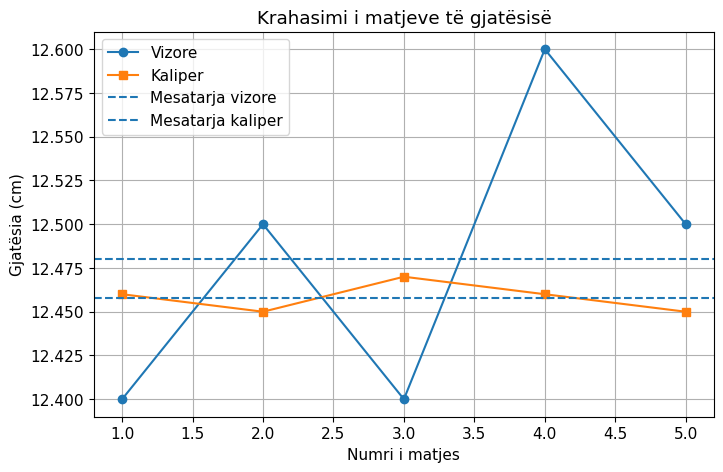

In [4]:
# Grafik i matjeve të gjatësisë
matjet = np.arange(1, len(gjatesi_vizore) + 1)

plt.plot(matjet, gjatesi_vizore, marker='o', label='Vizore')
plt.plot(matjet, gjatesi_kaliper, marker='s', label='Kaliper')
plt.axhline(rez_vizore['mesatarja'], linestyle='--', label='Mesatarja vizore')
plt.axhline(rez_kaliper['mesatarja'], linestyle='--', label='Mesatarja kaliper')
plt.xlabel('Numri i matjes')
plt.ylabel('Gjatësia (cm)')
plt.title('Krahasimi i matjeve të gjatësisë')
plt.legend()
plt.grid(True)
plt.show()


### Koment

Nga grafiku dhe rezultatet numerike mund të diskutohet:
- cili instrument është më preciz;
- nëse ka shpërndarje më të vogël të matjeve;
- nëse vërehet ndonjë zhvendosje sistematike midis instrumenteve.


# Pjesa B — Matja e Masës




In [5]:
# Shembull të dhënash për masën (në g)
masa = [153.2, 153.1, 153.3, 153.2, 153.2]
delta_peshore = 0.05  # g

rez_masa = analiza_matjeve(masa, delta_peshore)
printo_rezultatin('Masa', 'g', rez_masa)


--- Masa ---
Numri i matjeve: 5
Mesatarja = 153.2000 g
Devijimi standard = 0.0707 g
Pasiguria statistikore = 0.0316 g
Pasiguria instrumentale = 0.0500 g
Pasiguria totale = 0.0592 g
Rezultati final: Masa = (153.2000 ± 0.0592) g


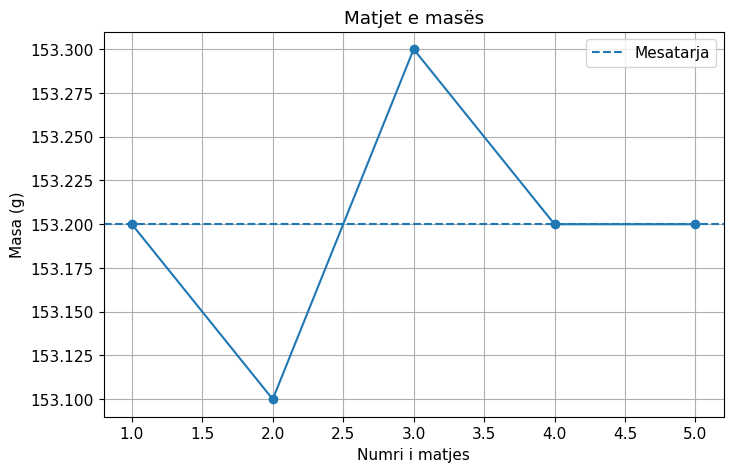

In [6]:
# Grafik i matjeve të masës
matjet_m = np.arange(1, len(masa) + 1)

plt.plot(matjet_m, masa, marker='o')
plt.axhline(rez_masa['mesatarja'], linestyle='--', label='Mesatarja')
plt.xlabel('Numri i matjes')
plt.ylabel('Masa (g)')
plt.title('Matjet e masës')
plt.legend()
plt.grid(True)
plt.show()


### Koment

Në këtë pjesë duhet të analizohet:
- nëse pesha është e qëndrueshme;
- nëse ka drift në matje;
- nëse vendosja e objektit ndikon te rezultati.


# Pjesa C — Matja e Kohës

Për kohën zakonisht ndikim të madh ka **koha e reagimit të njeriut**. Për këtë arsye bëhen më shumë matje.


In [7]:
# Shembull të dhënash për kohën (në s)
koha = [1.21, 1.18, 1.23, 1.20, 1.19, 1.22, 1.17, 1.21, 1.20, 1.19]
delta_kronometer = 0.01  # s

rez_koha = analiza_matjeve(koha, delta_kronometer)
printo_rezultatin('Koha', 's', rez_koha)


--- Koha ---
Numri i matjeve: 10
Mesatarja = 1.2000 s
Devijimi standard = 0.0183 s
Pasiguria statistikore = 0.0058 s
Pasiguria instrumentale = 0.0100 s
Pasiguria totale = 0.0115 s
Rezultati final: Koha = (1.2000 ± 0.0115) s


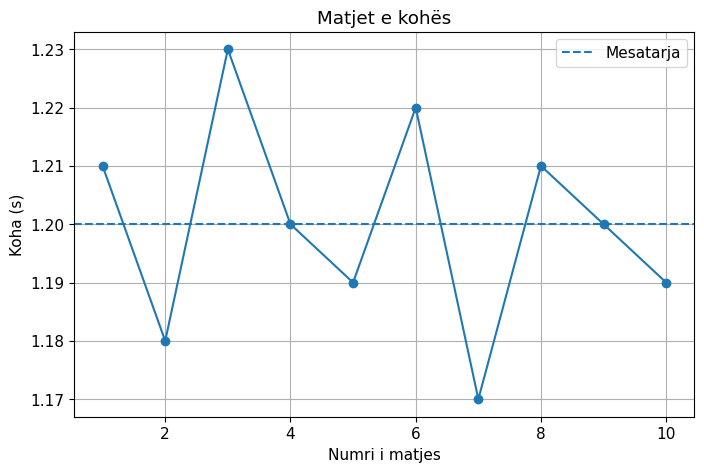

In [8]:
# Grafik i matjeve të kohës
matjet_k = np.arange(1, len(koha) + 1)

plt.plot(matjet_k, koha, marker='o')
plt.axhline(rez_koha['mesatarja'], linestyle='--', label='Mesatarja')
plt.xlabel('Numri i matjes')
plt.ylabel('Koha (s)')
plt.title('Matjet e kohës')
plt.legend()
plt.grid(True)
plt.show()


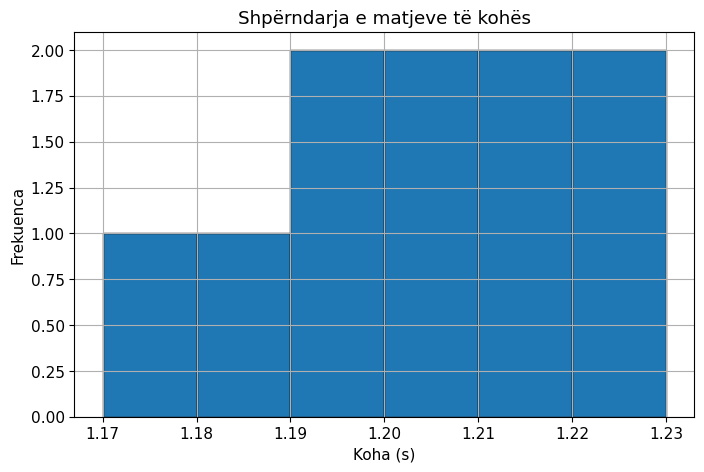

In [9]:
# Histogram për shpërndarjen e kohës
plt.hist(koha, bins=6, edgecolor='black')
plt.xlabel('Koha (s)')
plt.ylabel('Frekuenca')
plt.title('Shpërndarja e matjeve të kohës')
plt.grid(True)
plt.show()


### Koment

Në këtë pjesë diskutohet:
- ndikimi i reagimit njerëzor;
- ndryshueshmëria e matjeve;
- besueshmëria e mesatares si rezultat final.


# Krahasim përfundimtar i rezultateve

Këtu përmbledhim vlerat përfundimtare në mënyrë të organizuar.


In [10]:
rezultate = {
    'Gjatësia (vizore)': (rez_vizore['mesatarja'], rez_vizore['pasiguria_totale']),
    'Gjatësia (kaliper)': (rez_kaliper['mesatarja'], rez_kaliper['pasiguria_totale']),
    'Masa': (rez_masa['mesatarja'], rez_masa['pasiguria_totale']),
    'Koha': (rez_koha['mesatarja'], rez_koha['pasiguria_totale'])
}

for emri, (vlera, pasiguria) in rezultate.items():
    print(f"{emri}: {vlera:.4f} ± {pasiguria:.4f}")


Gjatësia (vizore): 12.4800 ± 0.0624
Gjatësia (kaliper): 12.4580 ± 0.0062
Masa: 153.2000 ± 0.0592
Koha: 1.2000 ± 0.0115


# Përfundim

Nga ky laborator kuptohet se:

- çdo matje përmban pasiguri;
- përsëritja e matjeve rrit besueshmërinë e rezultatit;
- instrumente të ndryshme japin precizion të ndryshëm;
- analiza eksperimentale nuk mbaron te leximi i numrit, por vazhdon me interpretimin kritik të tij.

Prandaj, rezultati përfundimtar duhet të paraqitet gjithmonë në formën:

$$x = (\text{vlera} \pm \text{pasiguria})\, \text{njësi}$$
